In [40]:
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIGURATION: Set the CSV file path for each (model, variant) pair
# ============================================================
CSV_CONFIG = {
    ("GPT-4o", "Minimal"): "/Volumes/Rachna-HD/GPTResults/Exp3BatchResults/investigate_undetected/investigation_GPT-4o_Minimal.csv",
    ("GPT-4o", "Method"): "/Volumes/Rachna-HD/GPTResults/Exp6BatchResults/investigate_undetected/investigation_GPT-4o_Method.csv",
    ("GPT-4o", "Class"): "/Volumes/Rachna-HD/GPTResults/Exp7BatchResultsOp2/investigate_undetected/investigation_GPT-4o_Class.csv",
    ("Qwen-480B", "Minimal"): "/Volumes/Rachna-HD/Qwen480Results/Exp3BatchResults/investigate_undetected/investigation_Qwen-480B_Minimal.csv",
    ("Qwen-480B", "Method"): "/Volumes/Rachna-HD/Qwen480Results/Exp6BatchResults/investigate_undetected/investigation_Qwen-480B_Method.csv",
    ("Qwen-480B", "Class"): "/Volumes/Rachna-HD/Qwen480Results/Exp7BatchResults/investigate_undetected/investigation_Qwen-480B_Class.csv",
    ("GPTOSS-120B", "Minimal"): "/Volumes/Rachna-HD/GPTOSSResults/Exp3BatchResults/investigate_undetected/investigation_GPTOSS-120B_Minimal.csv",
    ("GPTOSS-120B", "Method"): "/Volumes/Rachna-HD/GPTOSSResults/Exp6BatchResults/investigate_undetected/investigation_GPTOSS-120B_Method.csv",
    ("GPTOSS-120B", "Class"): "/Volumes/Rachna-HD/GPTOSSResults/Exp7BatchResults/investigate_undetected/investigation_GPTOSS-120B_Class.csv",
}
# ============================================================


def analyze_file(filepath: str) -> dict:
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df["hypothesis"] = df["hypothesis"].astype(str).str.strip().str.upper()
    df["custom_id"] = df["custom_id"].astype(str).str.strip()

    h1_ids = set(df.loc[df["hypothesis"] == "H1", "custom_id"])
    h2_ids = set(df.loc[df["hypothesis"] == "H2", "custom_id"])

    return {
        "total_rows": len(df),
        "h1_only": len(h1_ids - h2_ids),
        "h2_only": len(h2_ids - h1_ids),
        "both": len(h1_ids & h2_ids),
        "total_h1": len(h1_ids),
        "total_h2": len(h2_ids),
        "total_unique": len(h1_ids | h2_ids),
    }


def main():
    rows = []

    for (model, variant), filepath in CSV_CONFIG.items():
        if not Path(filepath).exists():
            print(f"WARNING: File not found for ({model}, {variant}): {filepath}")
            continue

        stats = analyze_file(filepath)
        rows.append({"model": model, "variant": variant, **stats})

    results = pd.DataFrame(rows)

    print("\n" + "=" * 90)
    print("HYPOTHESIS DISTRIBUTION BY MODEL-VARIANT PAIR")
    print("=" * 90)
    print(results.to_string(index=False))

    print("\n" + "-" * 90)
    totals = results[["total_rows", "h1_only", "h2_only", "both", "total_h1", "total_h2", "total_unique"]].sum()
    print(f"{'TOTAL':<18} {totals.to_dict()}")
    print("-" * 90)

    # Save to CSV
    output_path = "hypothesis_analysis_results.csv"
    results.to_csv(output_path, index=False)
    print(f"\nResults saved to {output_path}")


if __name__ == "__main__":
    main()


HYPOTHESIS DISTRIBUTION BY MODEL-VARIANT PAIR
      model variant  total_rows  h1_only  h2_only  both  total_h1  total_h2  total_unique
     GPT-4o Minimal         205       11        9     1        12        10            21
     GPT-4o  Method         164       10        7     2        12         9            19
     GPT-4o   Class          58        3        1     0         3         1             4
  Qwen-480B Minimal         116       11        2     1        12         3            14
  Qwen-480B  Method         204       10        3     1        11         4            14
  Qwen-480B   Class         262        8        4     1         9         5            13
GPTOSS-120B Minimal          16        4        0     1         5         1             5
GPTOSS-120B  Method          30        7        1     1         8         2             9
GPTOSS-120B   Class          60        9        0     1        10         1            10

----------------------------------------------------

Creating a H2 investigation file

In [1]:
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIGURATION: Set the CSV file path for each (model, variant) pair
# ============================================================
CSV_CONFIG = {
    ("GPT-4o", "Minimal"): "/Volumes/Rachna-HD/GPTResults/Exp3BatchResults/investigate_undetected/investigation_GPT-4o_Minimal.csv",
    ("GPT-4o", "Method"): "/Volumes/Rachna-HD/GPTResults/Exp6BatchResults/investigate_undetected/investigation_GPT-4o_Method.csv",
    ("GPT-4o", "Class"): "/Volumes/Rachna-HD/GPTResults/Exp7BatchResultsOp2/investigate_undetected/investigation_GPT-4o_Class.csv",
    ("Qwen-480B", "Minimal"): "/Volumes/Rachna-HD/Qwen480Results/Exp3BatchResults/investigate_undetected/investigation_Qwen-480B_Minimal.csv",
    ("Qwen-480B", "Method"): "/Volumes/Rachna-HD/Qwen480Results/Exp6BatchResults/investigate_undetected/investigation_Qwen-480B_Method.csv",
    ("Qwen-480B", "Class"): "/Volumes/Rachna-HD/Qwen480Results/Exp7BatchResults/investigate_undetected/investigation_Qwen-480B_Class.csv",
    ("GPTOSS-120B", "Minimal"): "/Volumes/Rachna-HD/GPTOSSResults/Exp3BatchResults/investigate_undetected/investigation_GPTOSS-120B_Minimal.csv",
    ("GPTOSS-120B", "Method"): "/Volumes/Rachna-HD/GPTOSSResults/Exp6BatchResults/investigate_undetected/investigation_GPTOSS-120B_Method.csv",
    ("GPTOSS-120B", "Class"): "/Volumes/Rachna-HD/GPTOSSResults/Exp7BatchResults/investigate_undetected/investigation_GPTOSS-120B_Class.csv",
}
# ============================================================
OUTPUT_DIR = Path("/Volumes/Rachna-HD/RQResultsForPaper/RQ3/H2_manual")

def analyze_file(filepath: str) -> dict:
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df["hypothesis"] = df["hypothesis"].astype(str).str.strip().str.upper()
    df["custom_id"] = df["custom_id"].astype(str).str.strip()

    h1_ids = set(df.loc[df["hypothesis"] == "H1", "custom_id"])
    h2_ids = set(df.loc[df["hypothesis"] == "H2", "custom_id"])

    return {
        "total_rows": len(df),
        "h1_only": len(h1_ids - h2_ids),
        "h2_only": len(h2_ids - h1_ids),
        "both": len(h1_ids & h2_ids),
        "total_h1": len(h1_ids),
        "total_h2": len(h2_ids),
        "total_unique": len(h1_ids | h2_ids),
    }





def export_h2_per_model():
    """Merge all variant CSVs per model, keep only H2 rows, save one CSV per model."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    models = {}
    for (model, variant), filepath in CSV_CONFIG.items():
        if not Path(filepath).exists():
            print(f"WARNING: File not found for ({model}, {variant}): {filepath}")
            continue
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()
        df["hypothesis"] = df["hypothesis"].astype(str).str.strip().str.upper()
        df["context_variant"] = variant  # ensure variant is tracked
        models.setdefault(model, []).append(df)

    for model, dfs in models.items():
        merged = pd.concat(dfs, ignore_index=True)
        h2_only = merged[merged["hypothesis"] == "H2"].drop_duplicates(subset=["custom_id", "context_variant"])
        out_path = OUTPUT_DIR / f"investigation_H2_{model}.csv"
        h2_only.to_csv(out_path, index=False)
        print(f"Saved {len(h2_only)} H2 rows for {model} → {out_path}")


def main():
    # ── Part 1: Hypothesis distribution analysis ──
    rows = []

    for (model, variant), filepath in CSV_CONFIG.items():
        if not Path(filepath).exists():
            print(f"WARNING: File not found for ({model}, {variant}): {filepath}")
            continue

        stats = analyze_file(filepath)
        rows.append({"model": model, "variant": variant, **stats})

    results = pd.DataFrame(rows)

    print("\n" + "=" * 90)
    print("HYPOTHESIS DISTRIBUTION BY MODEL-VARIANT PAIR")
    print("=" * 90)
    print(results.to_string(index=False))

    print("\n" + "-" * 90)
    totals = results[["total_rows", "h1_only", "h2_only", "both", "total_h1", "total_h2", "total_unique"]].sum()
    print(f"{'TOTAL':<18} {totals.to_dict()}")
    print("-" * 90)

    output_path = "hypothesis_analysis_results.csv"
    results.to_csv(output_path, index=False)
    print(f"\nResults saved to {output_path}")

    # ── Part 2: Export merged H2 files per model ──
    print("\n" + "=" * 90)
    print("EXPORTING H2 INVESTIGATION FILES PER MODEL")
    print("=" * 90)
    export_h2_per_model()


if __name__ == "__main__":
    main()


HYPOTHESIS DISTRIBUTION BY MODEL-VARIANT PAIR
      model variant  total_rows  h1_only  h2_only  both  total_h1  total_h2  total_unique
     GPT-4o Minimal         205       11        9     1        12        10            21
     GPT-4o  Method         164       10        7     2        12         9            19
     GPT-4o   Class          58        3        1     0         3         1             4
  Qwen-480B Minimal         116       11        2     1        12         3            14
  Qwen-480B  Method         204       10        3     1        11         4            14
  Qwen-480B   Class         262        8        4     1         9         5            13
GPTOSS-120B Minimal          16        4        0     1         5         1             5
GPTOSS-120B  Method          30        7        1     1         8         2             9
GPTOSS-120B   Class          60       10        0     1        11         1            11

----------------------------------------------------

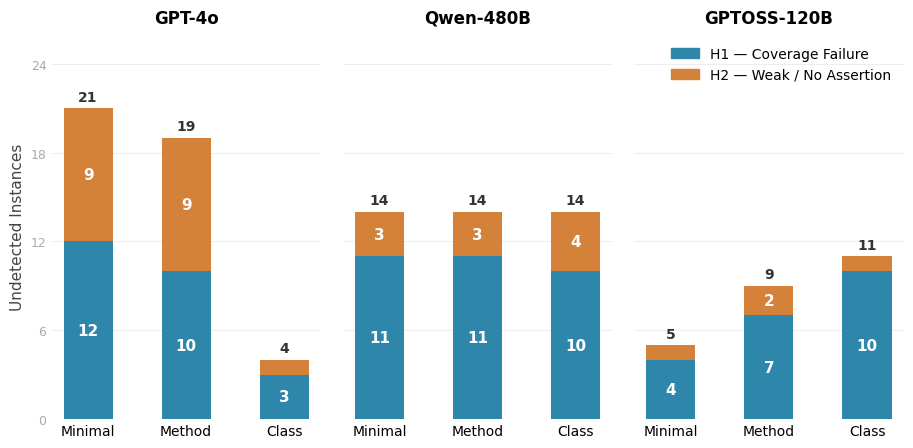

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = [
    dict(model='GPT-4o',      variant='Minimal', H1=12, H2=9),
    dict(model='GPT-4o',      variant='Method',  H1=10, H2=9),
    dict(model='GPT-4o',      variant='Class',   H1=3,  H2=1),
    dict(model='Qwen-480B',   variant='Minimal', H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Method',  H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Class',   H1=10, H2=4),
    dict(model='GPTOSS-120B', variant='Minimal', H1=4,  H2=1),
    dict(model='GPTOSS-120B', variant='Method',  H1=7,  H2=2),
    dict(model='GPTOSS-120B', variant='Class',   H1=10, H2=1),
]

MODELS   = ['GPT-4o', 'Qwen-480B', 'GPTOSS-120B']
VARIANTS = ['Minimal', 'Method', 'Class']

fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True)
plt.subplots_adjust(wspace=0.08)

x      = np.arange(len(VARIANTS))
bar_w  = 0.5

for ax, model in zip(axes, MODELS):
    model_data = [d for d in data if d['model'] == model]
    h1_vals = [d['H1'] for d in model_data]
    h2_vals = [d['H2'] for d in model_data]

    ax.bar(x, h1_vals, width=bar_w, color=H1_COLOR, linewidth=0, zorder=3)
    ax.bar(x, h2_vals, width=bar_w, bottom=h1_vals,
           color=H2_COLOR, linewidth=0, zorder=3)

    for i, (h1, h2) in enumerate(zip(h1_vals, h2_vals)):
        total = h1 + h2

        # H1 label inside — only if segment tall enough
        if h1 >= 2:
            ax.text(i, h1 / 2, str(h1),
                    ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')

        # H2 label inside — only if segment tall enough
        if h2 >= 2:
            ax.text(i, h1 + h2 / 2, str(h2),
                    ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')

        # total always on top
        ax.text(i, total + 0.3, str(total),
                ha='center', va='bottom',
                color='#333', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(VARIANTS, fontsize=10)
    ax.set_title(model, fontsize=12, fontweight='bold', pad=8)

    # clean look
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    ax.grid(axis='y', color='#eeeeee', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#aaa', labelsize=9)

axes[0].set_ylabel('Undetected Instances', fontsize=11, color='#444')
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
axes[0].set_ylim(0, 26)

# legend top right of last panel
axes[2].legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — Coverage Failure'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Weak / No Assertion'),
    ],
    loc='upper right', fontsize=10, frameon=False
)



plt.savefig('h1h2_instance_level.pdf', bbox_inches='tight', dpi=300)
plt.savefig('h1h2_instance_level.png', bbox_inches='tight', dpi=300)
plt.show()

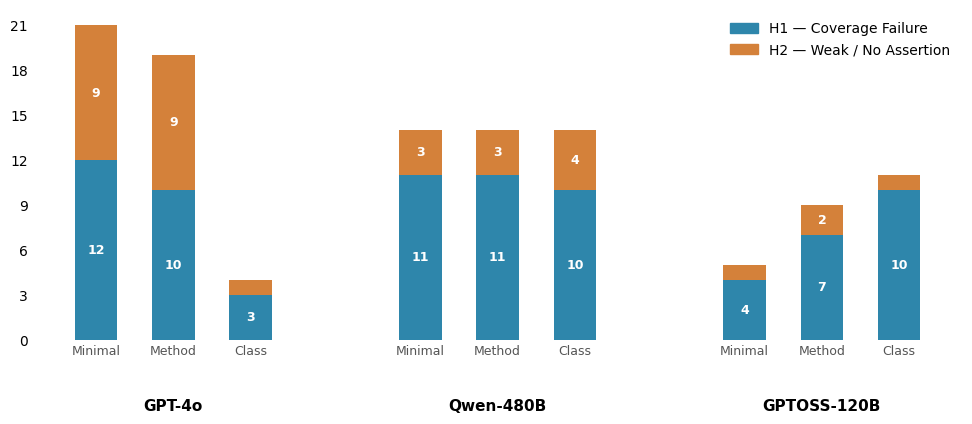

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = [
    dict(model='GPT-4o',      variant='Minimal', H1=12, H2=9),
    dict(model='GPT-4o',      variant='Method',  H1=10, H2=9),
    dict(model='GPT-4o',      variant='Class',   H1=3,  H2=1),
    dict(model='Qwen-480B',   variant='Minimal', H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Method',  H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Class',   H1=10, H2=4),
    dict(model='GPTOSS-120B', variant='Minimal', H1=4,  H2=1),
    dict(model='GPTOSS-120B', variant='Method',  H1=7,  H2=2),
    dict(model='GPTOSS-120B', variant='Class',   H1=10, H2=1),
]

MODELS   = ['GPT-4o', 'Qwen-480B', 'GPTOSS-120B']
VARIANTS = ['Minimal', 'Method', 'Class']

fig, ax = plt.subplots(figsize=(12,5))

bar_w = 0.55
group_gap = 1.2

# compute x positions
positions = []
x = 0
group_centers = []

for model in MODELS:
    start = x
    for variant in VARIANTS:
        positions.append((model, variant, x))
        x += 1
    group_centers.append((start + x - 1) / 2)
    x += group_gap

pos_map = {(m,v):p for m,v,p in positions}

# plot bars
for d in data:

    x = pos_map[(d['model'], d['variant'])]
    h1, h2 = d['H1'], d['H2']

    ax.bar(x, h1, width=bar_w, color=H1_COLOR, zorder=3)
    ax.bar(x, h2, width=bar_w, bottom=h1, color=H2_COLOR, zorder=3)

    if h1 >= 2:
        ax.text(x, h1/2, str(h1),
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

    if h2 >= 2:
        ax.text(x, h1 + h2/2, str(h2),
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

# variant ticks
variant_ticks = [p for _,_,p in positions]
ax.set_xticks(variant_ticks)
ax.set_xticklabels(VARIANTS * len(MODELS), fontsize=9, color='#555')

# model labels (axis transform prevents clipping)
for cx, model in zip(group_centers, MODELS):
    ax.text(cx, -0.18, model,
            ha='center', va='top',
            transform=ax.get_xaxis_transform(),
            fontsize=11, fontweight='bold')

# # vertical separators
# for i in range(1, len(group_centers)):
#     sep = (group_centers[i] + group_centers[i-1]) / 2 + 0.5
#     ax.axvline(sep, color='#e6e6e6', linestyle='--', lw=1)

# styling
# ax.set_ylim(0, 26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.set_ylabel('Undetected Instances', fontsize=11, color='#444')

# ax.grid(axis='y', color='#efefef')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — Coverage Failure'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Weak / No Assertion'),
    ],
    loc='upper right',
    frameon=False
)


plt.subplots_adjust(bottom=0.22)

plt.savefig('h1h2_instance_level.pdf', dpi=300, bbox_inches='tight')
plt.savefig('h1h2_instance_level.png', dpi=300, bbox_inches='tight')

plt.show()

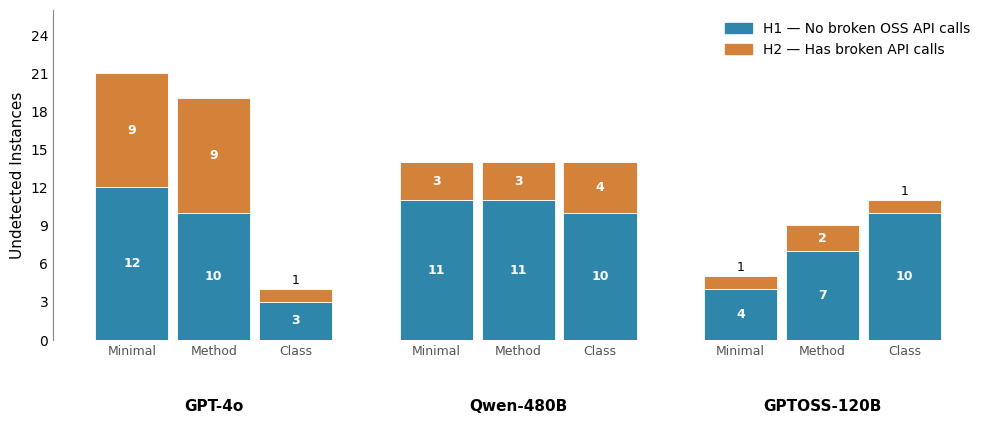

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = {
    'GPT-4o': {
        'Minimal': (12,9),
        'Method': (10,9),
        'Class': (3,1)
    },
    'Qwen-480B': {
        'Minimal': (11,3),
        'Method': (11,3),
        'Class': (10,4)
    },
    'GPTOSS-120B': {
        'Minimal': (4,1),
        'Method': (7,2),
        'Class': (10,1)
    }
}

MODELS   = list(data.keys())
VARIANTS = ['Minimal','Method','Class']

fig, ax = plt.subplots(figsize=(12,5))

bar_w = 0.6
variant_offsets = np.array([-1.12, 0, 1.12]) * bar_w
group_spacing = 2.5

x = np.arange(len(MODELS)) * group_spacing

for i, variant in enumerate(VARIANTS):

    xs = x + variant_offsets[i]

    h1 = [data[m][variant][0] for m in MODELS]
    h2 = [data[m][variant][1] for m in MODELS]

    ax.bar(xs, h1,
           width=bar_w,
           color=H1_COLOR,
           edgecolor='white',
           linewidth=0.6,
           zorder=3)

    ax.bar(xs, h2,
           bottom=h1,
           width=bar_w,
           color=H2_COLOR,
           edgecolor='white',
           linewidth=0.6,
           zorder=3)

    for xi, a, b in zip(xs, h1, h2):

        if a >= 2:
            ax.text(xi, a/2, str(a),
                    ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
        elif a > 0:
            ax.text(xi, a+0.2, str(a),
                    ha='center', va='bottom', fontsize=9)

        if b >= 2:
            ax.text(xi, a + b/2, str(b),
                    ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
        elif b > 0:
            ax.text(xi, a + b + 0.2, str(b),
                    ha='center', va='bottom', fontsize=9)

# variant labels
xticks = []
xticklabels = []

for i in range(len(MODELS)):
    for j in range(len(VARIANTS)):
        xticks.append(x[i] + variant_offsets[j])
        xticklabels.append(VARIANTS[j])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=9, color='#555')

# model labels
for xi, model in zip(x, MODELS):
    ax.text(xi, -0.18, model,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top',
            fontsize=11, fontweight='bold')

# y-axis
ax.set_ylim(0,26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Undetected Instances', fontsize=11)

# grid
# ax.grid(axis='y', color='#efefef')
ax.set_axisbelow(True)

# spines
for s in ['top','right','bottom']:
    ax.spines[s].set_visible(False)

ax.spines['left'].set_color('#888')
ax.spines['left'].set_linewidth(0.8)

ax.tick_params(length=0)

# legend
ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — No broken OSS API calls'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Has broken API calls')
    ],
    frameon=False,
    loc='upper right'
)

plt.subplots_adjust(bottom=0.22)

plt.savefig("h1h2_instance_level.pdf", dpi=300, bbox_inches="tight")
plt.savefig("h1h2_instance_level.png", dpi=300, bbox_inches="tight")

plt.show()

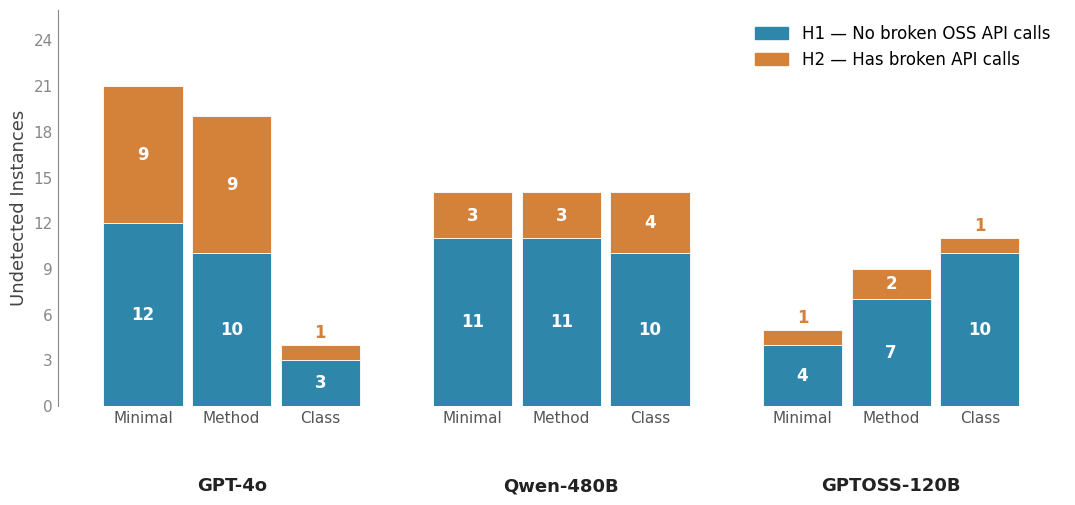

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = {
    'GPT-4o': {
        'Minimal': (12, 9),
        'Method':  (10, 9),
        'Class':   (3,  1)
    },
    'Qwen-480B': {
        'Minimal': (11, 3),
        'Method':  (11, 3),
        'Class':   (10, 4)
    },
    'GPTOSS-120B': {
        'Minimal': (4,  1),
        'Method':  (7,  2),
        'Class':   (10, 1)
    }
}

MODELS   = list(data.keys())
VARIANTS = ['Minimal', 'Method', 'Class']

fig, ax = plt.subplots(figsize=(13, 6))

bar_w           = 0.6
variant_offsets = np.array([-1.12, 0, 1.12]) * bar_w
group_spacing   = 2.5
x               = np.arange(len(MODELS)) * group_spacing

for i, variant in enumerate(VARIANTS):
    xs = x + variant_offsets[i]
    h1 = [data[m][variant][0] for m in MODELS]
    h2 = [data[m][variant][1] for m in MODELS]

    ax.bar(xs, h1, width=bar_w, color=H1_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)
    ax.bar(xs, h2, bottom=h1, width=bar_w, color=H2_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)

    for xi, a, b in zip(xs, h1, h2):
        # H1 label
        if a >= 2:
            ax.text(xi, a / 2, str(a),
                    ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold')
        elif a > 0:
            ax.text(xi, a + 0.2, str(a),
                    ha='center', va='bottom',
                    color=H1_COLOR, fontsize=12, fontweight='bold')

        # H2 label
        if b >= 2:
            ax.text(xi, a + b / 2, str(b),
                    ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold')
        elif b > 0:
            ax.text(xi, a + b + 0.2, str(b),
                    ha='center', va='bottom',
                    color=H2_COLOR, fontsize=12, fontweight='bold')

# variant labels under each bar
xticks, xticklabels = [], []
for i in range(len(MODELS)):
    for j in range(len(VARIANTS)):
        xticks.append(x[i] + variant_offsets[j])
        xticklabels.append(VARIANTS[j])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=11, color='#555')

# model labels centred under each group
for xi, model in zip(x, MODELS):
    ax.text(xi, -0.18, model,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top',
            fontsize=13, fontweight='bold', color='#222')

# y-axis
ax.set_ylim(0, 26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Undetected Instances', fontsize=13, color='#444')
ax.yaxis.set_tick_params(labelsize=11, labelcolor='#888')

# spines
for s in ['top', 'right', 'bottom']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#888')
ax.spines['left'].set_linewidth(0.8)
ax.tick_params(length=0)
ax.set_axisbelow(True)

# legend
ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — No broken OSS API calls'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Has broken API calls'),
    ],
    frameon=False, loc='upper right', fontsize=12
)

plt.subplots_adjust(bottom=0.22)
plt.savefig("h1h2_instance_level.pdf", dpi=300, bbox_inches="tight")
plt.savefig("h1h2_instance_level.png", dpi=300, bbox_inches="tight")
plt.show()

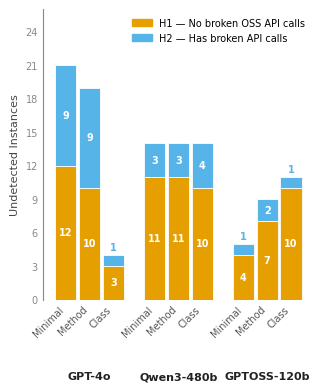

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

# ── Same Wong palette as Venn diagrams ────────────────────────────────────────
H1_COLOR = '#E69F00'  # orange  (was Minimal)
H2_COLOR = '#56B4E9'  # sky blue (was Method)

data = {
    'GPT-4o': {
        'Minimal': (12, 9),
        'Method':  (10, 9),
        'Class':   (3,  1)
    },
    'Qwen3-480b': {
        'Minimal': (11, 3),
        'Method':  (11, 3),
        'Class':   (10, 4)
    },
    'GPTOSS-120b': {
        'Minimal': (4,  1),
        'Method':  (7,  2),
        'Class':   (10, 1)
    }
}

MODELS   = list(data.keys())
VARIANTS = ['Minimal', 'Method', 'Class']

# ── Single-column width: 3.5 in wide, taller to accommodate labels ────────────
fig, ax = plt.subplots(figsize=(3.5, 5))

bar_w           = 0.6
variant_offsets = np.array([-1.12, 0, 1.12]) * bar_w
group_spacing   = 2.5
x               = np.arange(len(MODELS)) * group_spacing

for i, variant in enumerate(VARIANTS):
    xs = x + variant_offsets[i]
    h1 = [data[m][variant][0] for m in MODELS]
    h2 = [data[m][variant][1] for m in MODELS]

    ax.bar(xs, h1, width=bar_w, color=H1_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)
    ax.bar(xs, h2, bottom=h1, width=bar_w, color=H2_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)

    for xi, a, b in zip(xs, h1, h2):
        # H1 label
        if a >= 2:
            ax.text(xi, a / 2, str(a),
                    ha='center', va='center',
                    color='white', fontsize=7, fontweight='bold')
        elif a > 0:
            ax.text(xi, a + 0.2, str(a),
                    ha='center', va='bottom',
                    color=H1_COLOR, fontsize=7, fontweight='bold')

        # H2 label
        if b >= 2:
            ax.text(xi, a + b / 2, str(b),
                    ha='center', va='center',
                    color='white', fontsize=7, fontweight='bold')
        elif b > 0:
            ax.text(xi, a + b + 0.2, str(b),
                    ha='center', va='bottom',
                    color=H2_COLOR, fontsize=7, fontweight='bold')

# ── Variant labels under each bar ────────────────────────────────────────────
xticks, xticklabels = [], []
for i in range(len(MODELS)):
    for j in range(len(VARIANTS)):
        xticks.append(x[i] + variant_offsets[j])
        xticklabels.append(VARIANTS[j])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=7, color='#555', rotation=45, ha='right')

# ── Model labels centred under each group ────────────────────────────────────
for xi, model in zip(x, MODELS):
    ax.text(xi, -0.25, model,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top',
            fontsize=8, fontweight='bold', color='#222')

# ── Y-axis ────────────────────────────────────────────────────────────────────
ax.set_ylim(0, 26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Undetected Instances', fontsize=8, color='#444')
ax.yaxis.set_tick_params(labelsize=7, labelcolor='#888')

# ── Spines ────────────────────────────────────────────────────────────────────
for s in ['top', 'right', 'bottom']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#888')
ax.spines['left'].set_linewidth(0.8)
ax.tick_params(length=0)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — No broken OSS API calls'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Has broken API calls'),
    ],
    frameon=False, loc='upper right', fontsize=7
)

plt.subplots_adjust(bottom=0.30)
plt.savefig("h1h2_instance_level.pdf", dpi=300, bbox_inches="tight")
plt.savefig("h1h2_instance_level.png", dpi=300, bbox_inches="tight")
plt.show()

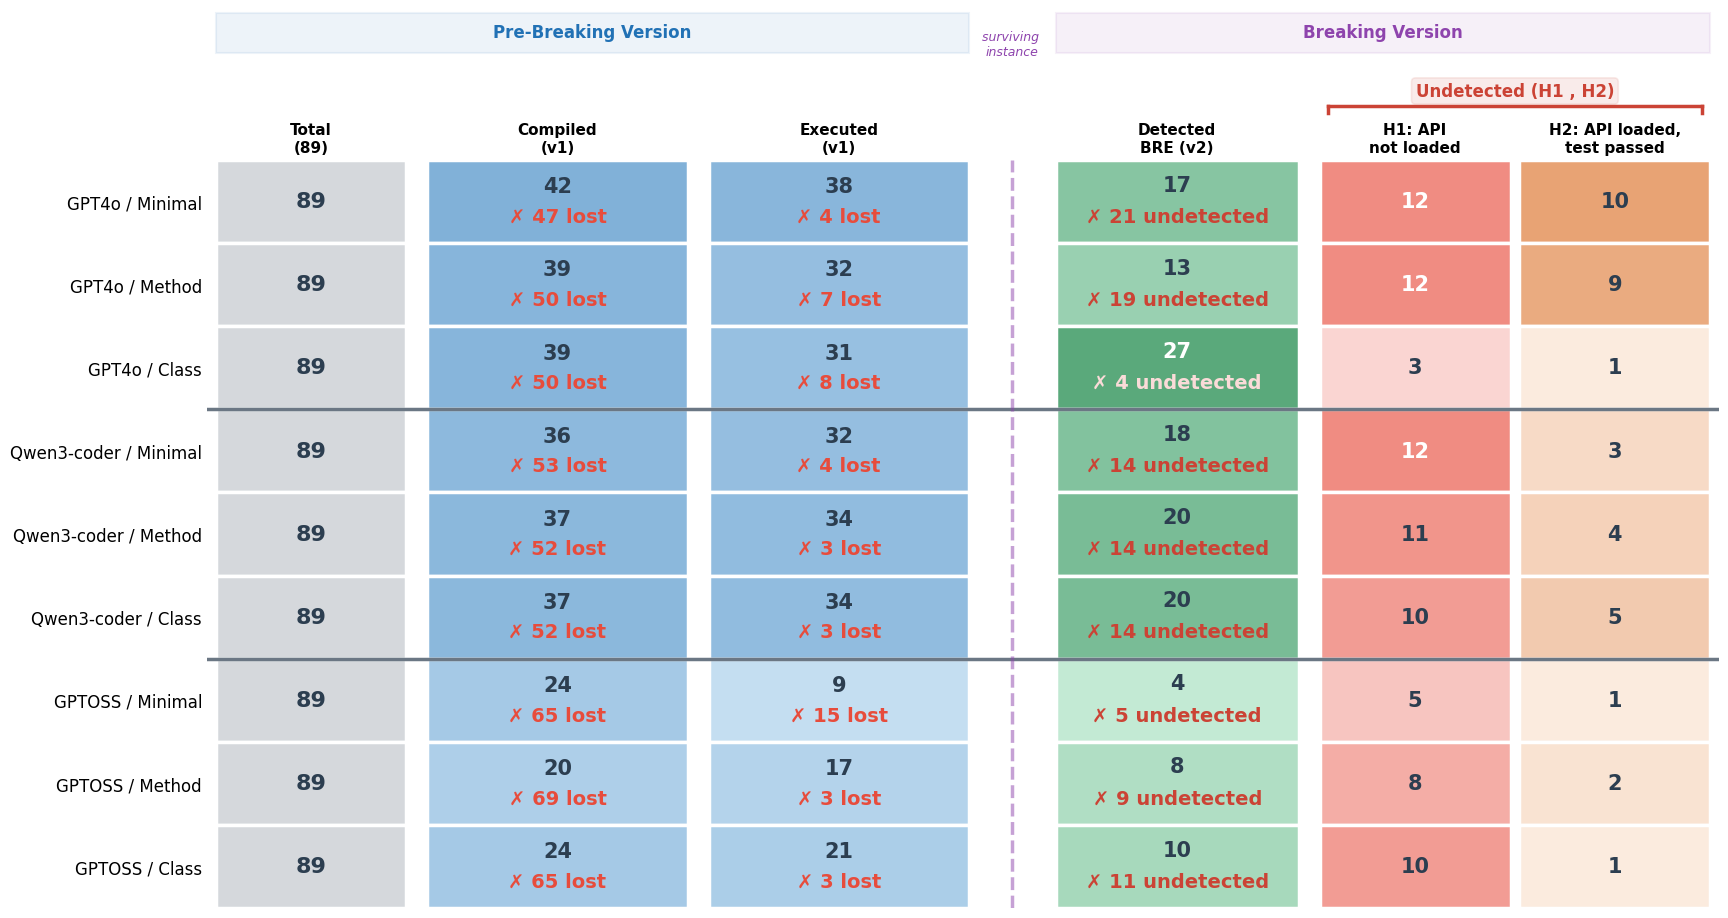

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, LinearSegmentedColormap

# ── Data ──────────────────────────────────────────────────────────────
models   = ["GPT4o", "GPT4o", "GPT4o", "Qwen3-coder", "Qwen3-coder", "Qwen3-coder", "GPTOSS", "GPTOSS", "GPTOSS"]
variants = ["Minimal", "Method", "Class", "Minimal", "Method", "Class", "Minimal", "Method", "Class"]

total_all     = [89]*9
compiled_all  = [42, 39, 39, 36, 37, 37, 24, 20, 24]
executed_all  = [38, 32, 31, 32, 34, 34,  9, 17, 21]
detected_all  = [17, 13, 27, 18, 20, 20,  4,  8, 10]
h1_all        = [12, 12,  3, 12, 11, 10,  5,  8, 10]
h2_all        = [ 10,  9,  1,  3,  4,  5,  1,  2,  1]

compile_fail = [t - c for t, c in zip(total_all, compiled_all)]
exec_fail    = [c - e for c, e in zip(compiled_all, executed_all)]
undetected   = [e - d for e, d in zip(executed_all, detected_all)]

row_labels = [f"{m} / {v}" for m, v in zip(models, variants)]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})

# ── Pipeline columns ─────────────────────────────────────────────────
ncols = 6
nrows = 9

matrix_abs = np.array([
    [89, compiled_all[i], executed_all[i],
     detected_all[i], h1_all[i], h2_all[i]]
    for i in range(9)
])

parent_vals = np.array([
    [89, 89, compiled_all[i],
     executed_all[i], executed_all[i], executed_all[i]]
    for i in range(9)
]).astype(float)

loss_vals = np.array([
    [0, compile_fail[i], exec_fail[i], 0, 0, 0]
    for i in range(9)
])

parent_vals[parent_vals == 0] = 1
matrix_pct = (matrix_abs / parent_vals * 100).astype(int)

# ── Color maps ────────────────────────────────────────────────────────
cmap_total  = LinearSegmentedColormap.from_list("tot",  ["#D5D8DC", "#5D6D7E"])
cmap_main   = LinearSegmentedColormap.from_list("main", ["#D6EAF8", "#2171B5"])
cmap_detect = LinearSegmentedColormap.from_list("det",  ["#D5F5E3", "#1E8449"])
cmap_h1     = LinearSegmentedColormap.from_list("h1",   ["#FDEDEC", "#E74C3C"])
cmap_h2     = LinearSegmentedColormap.from_list("h2",   ["#FDF2E9", "#D35400"])

col_cmap = {
    0: (cmap_total,  89, 89),
    1: (cmap_main,    0, 89),
    2: (cmap_main,    0, 89),
    3: (cmap_detect,  0, 40),
    4: (cmap_h1,      0, 20),
    5: (cmap_h2,      0, 20),
}

loss_cols = {1, 2}

# =====================================================================
# FIGURE
# =====================================================================
fig, ax = plt.subplots(figsize=(18, 11))

col_widths = [1.1, 1.5, 1.5, 1.4, 1.1, 1.1]
col_gaps   = [0.12, 0.12, 0.5, 0.12, 0.05, 0]

col_x = [0]
for k in range(ncols - 1):
    col_x.append(col_x[-1] + col_widths[k] + col_gaps[k])
total_w = col_x[-1] + col_widths[-1]

CELL_H = 1.15  # taller cells for breathing room

for i in range(nrows):
    for j in range(ncols):
        cmap, vmin, vmax = col_cmap[j]
        norm = Normalize(vmin=vmin, vmax=vmax)
        color = cmap(norm(matrix_abs[i, j]))

        x0 = col_x[j]
        w = col_widths[j]

        rect = plt.Rectangle((x0, i * CELL_H), w, CELL_H,
                              facecolor=color, edgecolor="white", lw=2.5)
        ax.add_patch(rect)

        val = matrix_abs[i, j]
        pct = matrix_pct[i, j]
        intensity = norm(val)
        txt_color = "white" if intensity > 0.55 else "#2C3E50"
        cx = x0 + w / 2
        cy = i * CELL_H

        if j == 0:
            ax.text(cx, cy + CELL_H * 0.5, f"{val}", ha="center", va="center",
                    fontsize=16, fontweight="bold", color=txt_color)

        elif j in loss_cols:
            ax.text(cx, cy + CELL_H * 0.32, f"{val}", ha="center", va="center",
                    fontsize=15, fontweight="bold", color=txt_color)
            lost = loss_vals[i, j]
            loss_color = "#E74C3C" if intensity < 0.55 else "#FADBD8"
            ax.text(cx, cy + CELL_H * 0.68, f"✗ {lost} lost", ha="center", va="center",
                    fontsize=14, fontweight="bold", color=loss_color)

        elif j == 3:
            ax.text(cx, cy + CELL_H * 0.3, f"{val}", ha="center", va="center",
                    fontsize=15, fontweight="bold", color=txt_color)
            undet = undetected[i]
            undet_color = "#CB4335" if intensity < 0.55 else "#FADBD8"
            ax.text(cx, cy + CELL_H * 0.68, f"✗ {undet} undetected",
                    ha="center", va="center",
                    fontsize=14, fontweight="bold", color=undet_color)

        else:
            ax.text(cx, cy + CELL_H * 0.5, f"{val}", ha="center", va="center",
                    fontsize=15, fontweight="bold", color=txt_color)

# ── Axis setup ────────────────────────────────────────────────────────
ax.set_xlim(-0.05, total_w + 0.05)
ax.set_ylim(0, nrows * CELL_H)
ax.invert_yaxis()

col_header_labels = [
    "Total\n(89)", "Compiled\n(v1)", "Executed\n(v1)",
    "Detected\nBRE (v2)",
    "H1: API\nnot loaded",
    "H2: API loaded,\ntest passed",
]
ax.set_xticks([col_x[j] + col_widths[j] / 2 for j in range(ncols)])
ax.set_xticklabels(col_header_labels, fontsize=11, fontweight="bold")
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")

ax.set_yticks([i * CELL_H + CELL_H / 2 for i in range(nrows)])
ax.set_yticklabels(row_labels, fontsize=12)
ax.tick_params(axis="both", length=0)

# ── Model group separators ───────────────────────────────────────────
for sep in [3, 6]:
    ax.axhline(sep * CELL_H, color="#2C3E50", lw=2.5, alpha=0.7)

# ── Version boundary ─────────────────────────────────────────────────
boundary_x = col_x[2] + col_widths[2] + col_gaps[2] / 2
ax.axvline(boundary_x, color="#8E44AD", lw=2.5, ls="--", alpha=0.5,
           ymin=0, ymax=1)

# ── Phase labels ─────────────────────────────────────────────────────
phase_y = -1.9 * CELL_H

pre_left  = col_x[0]
pre_right = col_x[2] + col_widths[2]
pre_mid   = (pre_left + pre_right) / 2
ax.add_patch(plt.Rectangle((pre_left, phase_y + 0.15), pre_right - pre_left, 0.55,
             facecolor="#2171B5", alpha=0.08, edgecolor="#2171B5", lw=1.5,
             clip_on=False, transform=ax.transData))
ax.text(pre_mid, phase_y + 0.42, "Pre-Breaking Version", ha="center", va="center",
        fontsize=12, fontweight="bold", color="#2171B5", clip_on=False)
ax.text(pre_mid, phase_y + 0.1, " ",
        ha="center", va="top", fontsize=9.5, color="#5DADE2", fontstyle="italic",
        clip_on=False)

brk_left  = col_x[3]
brk_right = col_x[5] + col_widths[5]
brk_mid   = (brk_left + brk_right) / 2
ax.add_patch(plt.Rectangle((brk_left, phase_y + 0.15), brk_right - brk_left, 0.55,
             facecolor="#8E44AD", alpha=0.08, edgecolor="#8E44AD", lw=1.5,
             clip_on=False, transform=ax.transData))
ax.text(brk_mid, phase_y + 0.42, "Breaking Version", ha="center", va="center",
        fontsize=12, fontweight="bold", color="#8E44AD", clip_on=False)
ax.text(brk_mid, phase_y + 0.1, " ",
        ha="center", va="top", fontsize=9.5, color="#AF7AC5", fontstyle="italic",
        clip_on=False)

# Transfer arrow
ax.annotate("",
            xy=(brk_left - 0.08, phase_y + 0.42),
            xytext=(pre_right + 0.08, phase_y + 0.42),
            arrowprops=dict(arrowstyle="->,head_width=0.3,head_length=0.15",
                            color="#8E44AD", lw=2.5),
            clip_on=False)
ax.text(boundary_x, phase_y + 0.78, "surviving \ninstance",
        ha="center", va="bottom", fontsize=9, color="#8E44AD",
        fontstyle="italic", clip_on=False)

# ── Pipeline flow arrows ─────────────────────────────────────────────
arrow_y = -0.7
arrow_props_main = dict(arrowstyle="->,head_width=0.3,head_length=0.15",
                        color="#7F8C8D", lw=2)

for c1, c2 in [(0, 1), (1, 2)]:
    x1 = col_x[c1] + col_widths[c1] / 2
    x2 = col_x[c2] + col_widths[c2] / 2
    ax.annotate("", xy=(x2 - 0.2, arrow_y), xytext=(x1 + 0.2, arrow_y),
                arrowprops=arrow_props_main, clip_on=False)

# Executed → Detected (green)
ex_cx  = col_x[2] + col_widths[2] / 2
det_cx = col_x[3] + col_widths[3] / 2
ax.annotate("", xy=(det_cx - 0.15, arrow_y + 0.03), xytext=(ex_cx + 0.2, arrow_y),
            arrowprops=dict(arrowstyle="->,head_width=0.25,head_length=0.12",
                            color="#1E8449", lw=2, connectionstyle="arc3,rad=0.1"),
            clip_on=False)

# Executed → H1/H2 bracket (red dashed)
h1_left_edge = col_x[4]
h2_right_edge = col_x[5] + col_widths[5]
bracket_mid = (h1_left_edge + h2_right_edge) / 2
ax.annotate("", xy=(bracket_mid, arrow_y + 0.03), xytext=(ex_cx + 0.2, arrow_y),
            arrowprops=dict(arrowstyle="->,head_width=0.2,head_length=0.1",
                            color="#CB4335", lw=1.8, ls="--",
                            connectionstyle="arc3,rad=-0.12"),
            clip_on=False)

# ── Undetected bracket over H1 + H2 ──────────────────────────────────
bracket_top = -0.75
ax.plot([h1_left_edge + 0.05, h2_right_edge - 0.05], [bracket_top, bracket_top],
        color="#CB4335", lw=2.5, clip_on=False)
ax.plot([h1_left_edge + 0.05, h1_left_edge + 0.05], [bracket_top, bracket_top + 0.1],
        color="#CB4335", lw=2.5, clip_on=False)
ax.plot([h2_right_edge - 0.05, h2_right_edge - 0.05], [bracket_top, bracket_top + 0.1],
        color="#CB4335", lw=2.5, clip_on=False)
ax.text(bracket_mid, bracket_top - 0.08, "Undetected (H1 , H2)", ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#CB4335",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="#CB4335", alpha=0.1,
                  edgecolor="#CB4335", lw=1.2), clip_on=False)

fig.tight_layout()
plt.subplots_adjust(top=0.70, left=0.14, right=0.98, bottom=0.02)
plt.savefig("rq3_pipeline_heatmap.pdf", bbox_inches="tight", dpi=300)
plt.show()

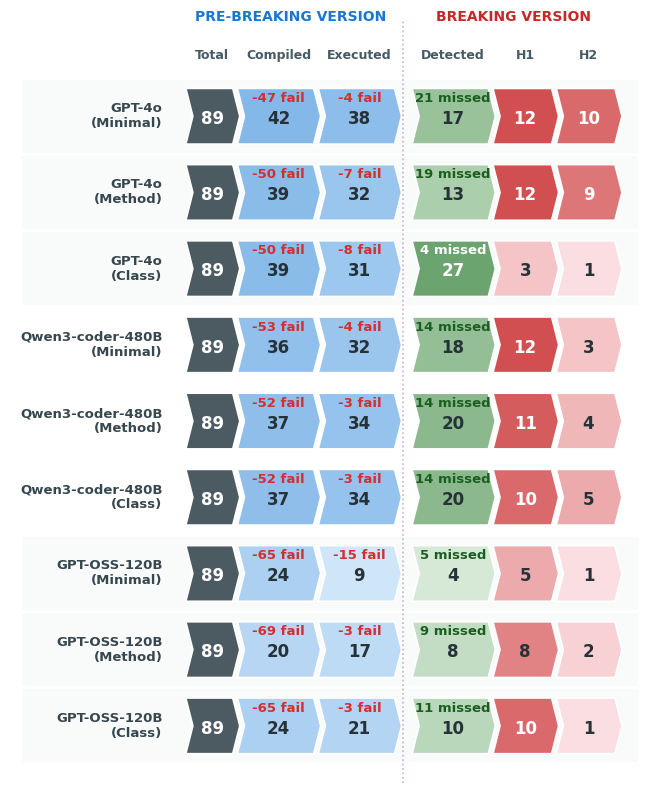

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Rectangle, Polygon

# ── Configuration ──────────────────────────────────────────────────
plt.rcParams.update({"font.family": "sans-serif", "font.size": 9})

# ── Data ────────────────────────────────────────────────────────────
models = ["GPT-4o", "Qwen3-coder-480B", "GPT-OSS-120B"]
variants = ["Minimal", "Method", "Class"]
row_labels = [f"{m}\n({v})" for m in models for v in variants]

data = {
    "total": [89]*9,
    "compiled": [42, 39, 39, 36, 37, 37, 24, 20, 24],
    "executed": [38, 32, 31, 32, 34, 34, 9, 17, 21],
    "detected": [17, 13, 27, 18, 20, 20, 4, 8, 10],
    "h1":       [12, 12, 3, 12, 11, 10, 5, 8, 10],
    "h2":       [10, 9, 1, 3, 4, 5, 1, 2, 1]
}

# ── Refined Palette ────────────────────────────────────────────────
COLORS = {
    "v1_blue":    ["#E3F2FD", "#1976D2"], 
    "v2_green":   ["#E8F5E9", "#2E7D32"], 
    "v2_red":     ["#FFEBEE", "#C62828"], 
    "neutral":    ["#F8F9F9", "#37474F"], 
    "loss_bold":  "#D32F2F",               
    "success_bold": "#1B5E20"              
}

def draw_sleek_chevron(ax, x, y, w, h, val, cmap_colors, vmin, vmax, subtext=None, subcolor=None):
    cmap = LinearSegmentedColormap.from_list("custom", cmap_colors)
    norm = Normalize(vmin=vmin, vmax=vmax)
    facecolor = cmap(norm(val))
    
    # Sleek Chevron Geometry
    pw = 0.12 # Pointer width
    pts = np.array([
        [x, y], [x + w, y], [x + w + pw, y + h/2], 
        [x + w, y + h], [x, y + h], [x + pw, y + h/2]
    ])
    ax.add_patch(Polygon(pts, facecolor=facecolor, edgecolor="white", lw=1.2, zorder=1))
    
    is_dark = norm(val) > 0.55
    text_color = "white" if is_dark else "#263238"
    
    # Value (Centered vertically)
    ax.text(x + w/2 + 0.05, y + h * 0.45, str(val), ha='center', va='center', 
            fontsize=12, fontweight='bold', color=text_color, zorder=2)
    
    # High-Visibility Failure Metrics
    if subtext:
        sc = subcolor if not is_dark else "white"
        ax.text(x + w/2 + 0.05, y + h * 0.82, subtext, ha='center', va='center', 
                fontsize=9.5, fontweight='black', color=sc, zorder=2)

# ── Setup Figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_aspect('equal')

# Condensed Layout
col_widths = [0.8, 1.3, 1.3, 1.3, 1.0, 1.0]
col_gaps   = [0.08, 0.08, 0.3, 0.08, 0.08, 0] 
col_x = [0]
for i in range(len(col_widths)-1):
    col_x.append(col_x[-1] + col_widths[i] + col_gaps[i])

CELL_H = 0.95  # Reduced height for sleekness
for i in range(9):
    y = (8 - i) * (CELL_H + 0.35) # Add margin between rows
    
    # Shaded Lane Background
    if (i // 3) % 2 == 0:
        ax.add_patch(Rectangle((-2.8, y-0.15), col_x[-1]+col_widths[-1]+3.2, CELL_H+0.3, 
                               facecolor="#F7F9F9", zorder=-10, alpha=0.7))

    draw_sleek_chevron(ax, col_x[0], y, col_widths[0], CELL_H, 89, COLORS["neutral"], 0, 100)
    
    # Failures are now larger and more aggressive
    lost_c = 89 - data["compiled"][i]
    draw_sleek_chevron(ax, col_x[1], y, col_widths[1], CELL_H, data["compiled"][i], 
                         COLORS["v1_blue"], 0, 89, f"-{lost_c} fail", COLORS["loss_bold"])
    
    lost_e = data["compiled"][i] - data["executed"][i]
    draw_sleek_chevron(ax, col_x[2], y, col_widths[2], CELL_H, data["executed"][i], 
                         COLORS["v1_blue"], 0, 89, f"-{lost_e} fail", COLORS["loss_bold"])
    
    undet = data["executed"][i] - data["detected"][i]
    draw_sleek_chevron(ax, col_x[3], y, col_widths[3], CELL_H, data["detected"][i], 
                         COLORS["v2_green"], 0, 40, f"{undet} missed", COLORS["success_bold"])
    
    draw_sleek_chevron(ax, col_x[4], y, col_widths[4], CELL_H, data["h1"][i], COLORS["v2_red"], 0, 15)
    draw_sleek_chevron(ax, col_x[5], y, col_widths[5], CELL_H, data["h2"][i], COLORS["v2_red"], 0, 15)

# ── Annotations ────────────────────────────────────────────────────
header_y = 9 * (CELL_H + 0.35)

# Group Headers
ax.text((col_x[0]+col_x[2]+col_widths[2])/2, header_y + 0.8, "PRE-BREAKING VERSION", 
        color="#1976D2", fontweight='black', ha='center', fontsize=10)
ax.text((col_x[3]+col_x[5]+col_widths[5])/2, header_y + 0.8, "BREAKING VERSION", 
        color="#C62828", fontweight='black', ha='center', fontsize=10)

# Column Names
headers = ["Total", "Compiled", "Executed", "Detected", "H1", "H2"]
for j, h in enumerate(headers):
    ax.text(col_x[j] + col_widths[j]/2 + 0.05, header_y + 0.1, h, 
            ha='center', va='bottom', fontweight='bold', fontsize=9, color="#455A64")

# Separators
bx = col_x[2] + col_widths[2] + col_gaps[2]/2
ax.axvline(bx, color="#7D3C98", ls=":", lw=1.2, alpha=0.4)
ax.text(bx, header_y + 0.65, " ", ha='center', va='top', fontstyle='italic', color="#7D3C98", fontsize=7.5)

# Row Labels
for i, label in enumerate(row_labels):
    ax.text(col_x[0] - 0.4, (8 - i) * (CELL_H + 0.35) + CELL_H/2, label, 
            ha='right', va='center', fontweight='bold', color="#37474F", fontsize=9.5)

ax.set_xlim(-3.0, col_x[-1] + col_widths[-1] + 0.5)
ax.set_ylim(-0.5, 12.5)
ax.axis('off')

plt.tight_layout()
plt.show()

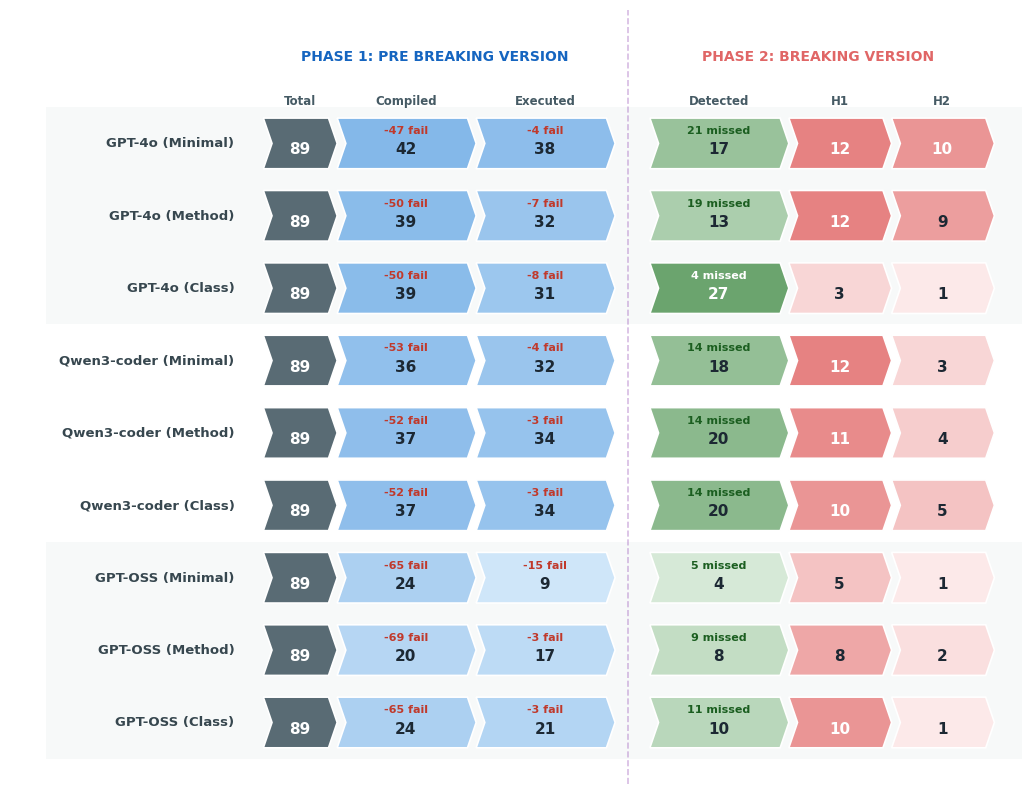

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Rectangle, Polygon

# ── Clean Dashboard Configuration ──────────────────────────────────
plt.rcParams.update({"font.family": "sans-serif", "font.size": 8.5})

# ── Data ────────────────────────────────────────────────────────────
models = ["GPT-4o", "Qwen3-coder", "GPT-OSS"]
variants = ["Minimal", "Method", "Class"]
row_labels = [f"{m} ({v})" for m in models for v in variants]

data = {
    "total": [89]*9,
    "compiled": [42, 39, 39, 36, 37, 37, 24, 20, 24],
    "executed": [38, 32, 31, 32, 34, 34, 9, 17, 21],
    "detected": [17, 13, 27, 18, 20, 20, 4, 8, 10],
    "h1":       [12, 12, 3, 12, 11, 10, 5, 8, 10],
    "h2":       [10, 9, 1, 3, 4, 5, 1, 2, 1]
}

# ── Professional Palette ────────────────────────────────────────────
COLORS = {
    "v1_blue":    ["#E3F2FD", "#1976D2"], 
    "v2_green":   ["#E8F5E9", "#2E7D32"], 
    "v2_failure": ["#FEF2F2", "#E06666"], 
    "neutral":    ["#F8F9F9", "#455A64"], 
    "loss_text":  "#C0392B",               
    "success_text": "#1B5E20"              
}

def draw_clean_chevron(ax, x, y, w, h, val, cmap_colors, vmin, vmax, subtext=None, subcolor=None):
    cmap = LinearSegmentedColormap.from_list("custom", cmap_colors)
    norm = Normalize(vmin=vmin, vmax=vmax)
    facecolor = cmap(norm(val))
    
    pw = 0.12 
    pts = np.array([
        [x, y], [x + w, y], [x + w + pw, y + h/2], 
        [x + w, y + h], [x, y + h], [x + pw, y + h/2]
    ])
    ax.add_patch(Polygon(pts, facecolor=facecolor, edgecolor="white", lw=1.2, zorder=1))
    
    is_dark = norm(val) > 0.6
    text_color = "white" if is_dark else "#1C2833"
    
    ax.text(x + w/2 + 0.05, y + h * 0.38, str(val), ha='center', va='center', 
            fontsize=11, fontweight='bold', color=text_color, zorder=2)
    
    if subtext:
        sc = subcolor if not is_dark else "white"
        ax.text(x + w/2 + 0.05, y + h * 0.75, subtext, ha='center', va='center', 
                fontsize=8, fontweight='bold', color=sc, zorder=2)

# ── Setup Figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_aspect('equal')

col_widths = [0.9, 1.8, 1.8, 1.8, 1.3, 1.3]
col_gaps   = [0.12, 0.12, 0.6, 0.12, 0.12, 0] 
col_x = [0]
for i in range(len(col_widths)-1):
    col_x.append(col_x[-1] + col_widths[i] + col_gaps[i])

CELL_H = 0.7  
ROW_GAP = 0.3 

for i in range(9):
    y = (8 - i) * (CELL_H + ROW_GAP)
    
    if (i // 3) % 2 == 0:
        ax.add_patch(Rectangle((-3.0, y-0.15), col_x[-1]+col_widths[-1]+3.5, CELL_H+0.3, 
                               facecolor="#F4F7F7", zorder=-10, alpha=0.7))

    draw_clean_chevron(ax, col_x[0], y, col_widths[0], CELL_H, 89, COLORS["neutral"], 0, 100)
    
    lost_c = 89 - data["compiled"][i]
    draw_clean_chevron(ax, col_x[1], y, col_widths[1], CELL_H, data["compiled"][i], 
                         COLORS["v1_blue"], 0, 89, f"-{lost_c} fail", COLORS["loss_text"])
    
    lost_e = data["compiled"][i] - data["executed"][i]
    draw_clean_chevron(ax, col_x[2], y, col_widths[2], CELL_H, data["executed"][i], 
                         COLORS["v1_blue"], 0, 89, f"-{lost_e} fail", COLORS["loss_text"])
    
    undet = data["executed"][i] - data["detected"][i]
    draw_clean_chevron(ax, col_x[3], y, col_widths[3], CELL_H, data["detected"][i], 
                         COLORS["v2_green"], 0, 40, f"{undet} missed", COLORS["success_text"])
    
    draw_clean_chevron(ax, col_x[4], y, col_widths[4], CELL_H, data["h1"][i], COLORS["v2_failure"], 0, 15)
    draw_clean_chevron(ax, col_x[5], y, col_widths[5], CELL_H, data["h2"][i], COLORS["v2_failure"], 0, 15)

# ── Tightened Headers ──────────────────────────────────────────────
# We calculate the top of the first row (y_top_row) and build from there
y_top_row = 8 * (CELL_H + ROW_GAP) + CELL_H

# Column Labels (Lowered to sit right above the chevrons)
headers = ["Total", "Compiled", "Executed", "Detected", "H1", "H2"]
for j, h in enumerate(headers):
    ax.text(col_x[j] + col_widths[j]/2 + 0.05, y_top_row + 0.15, h, 
            ha='center', va='bottom', fontweight='bold', fontsize=8.5, color="#455A64")

# Phase Titles (Lowered to sit right above column headers)
ax.text((col_x[0]+col_x[2]+col_widths[2])/2, y_top_row + 0.8, "PHASE 1: PRE BREAKING VERSION", 
        color="#1565C0", fontweight='black', ha='center', fontsize=10)
ax.text((col_x[3]+col_x[5]+col_widths[5])/2, y_top_row + 0.8, "PHASE 2: BREAKING VERSION", 
        color="#E06666", fontweight='black', ha='center', fontsize=10)

# Separator line and "surviving instances" label
bx = col_x[2] + col_widths[2] + col_gaps[2]/2
ax.axvline(bx, color="#7B1FA2", ls="--", lw=1.2, alpha=0.3)
ax.text(bx, y_top_row + 0.5, "", ha='center', va='bottom', 
        fontstyle='italic', color="#7B1FA2", fontsize=7.5)

# Row Labels
for i, label in enumerate(row_labels):
    ax.text(col_x[0] - 0.4, (8 - i) * (CELL_H + ROW_GAP) + CELL_H/2, label, 
            ha='right', va='center', fontweight='bold', color="#37474F", fontsize=9.5)

# Tighten the limits to remove top whitespace
ax.set_xlim(-3.5, col_x[-1] + col_widths[-1] + 0.5)
ax.set_ylim(-0.5, y_top_row + 1.5) 
ax.axis('off')

plt.tight_layout()
plt.show()